# 🧠 Anomaly Detection in Network Traffic Data
### Midterm Project, Advanced Machine Learning
Team: Pradeep Yellapu, Rasagna Tirumani, Roshan Syed
Dataset: UNSW-NB15

This notebook contains all code for dataset loading, preprocessing, feature selection, and supervised modeling.


## Step 1  Dataset Loading and EDA
Paste all your EDA and visualization code here.

In [1]:
!free -h   # Linux/Mac
# or
!wmic OS get FreePhysicalMemory /Format:List   # Windows

              total        used        free      shared  buff/cache   available
Mem:          7.6Gi       3.0Gi       4.2Gi       2.0Mi       454Mi       4.4Gi
Swap:         2.0Gi       2.0Gi          0B
/usr/bin/sh: 1: wmic: not found


In [7]:
import json, os
selected_numeric = ['sttl', 'dttl', 'Sload', 'ct_state_ttl', 'smeansz',
                    'sbytes', 'dur', 'Dintpkt', 'dmeansz', 'dbytes']

os.makedirs("outputs", exist_ok=True)
json.dump(selected_numeric, open("outputs/selected_numeric.json", "w"))
print("File created successfully:", selected_numeric)

File created successfully: ['sttl', 'dttl', 'Sload', 'ct_state_ttl', 'smeansz', 'sbytes', 'dur', 'Dintpkt', 'dmeansz', 'dbytes']


In [8]:
from anomaly_utils import load_unsw_from_zip
from sklearn.model_selection import train_test_split
import pandas as pd, numpy as np, json, os, glob, zipfile

def load_unsw_sample(zip_path, extract_dir="./data", sample_size=70000):
    import pandas as pd, os, glob, zipfile
    from anomaly_utils import UNSW_COLS

    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)

    csvs = sorted(glob.glob(f"{extract_dir}/**/*.csv", recursive=True))
    dfs = []
    for p in csvs:
        part = pd.read_csv(p, encoding="latin1", header=None, names=UNSW_COLS, low_memory=False, nrows=20000)
        dfs.append(part)
        if sum(len(x) for x in dfs) >= sample_size:
            break
    df = pd.concat(dfs, ignore_index=True).sample(sample_size, random_state=42)
    return df

# === Step 1: Load a sample ===
df = load_unsw_sample("archive.zip", extract_dir="./data", sample_size=70000)
print(f"Loaded {len(df):,} rows for modeling")

# === Step 2: Clean and define target ===
df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
y = df["label"]
X = df.drop(columns=["label"])

# === Step 3: Separate columns ===
cat_cols = ["proto", "service", "state", "attack_cat"]
num_cols = [c for c in X.columns if c not in cat_cols]

# === Step 4: Load selected numeric features ===
selected_numeric = json.load(open("outputs/selected_numeric.json"))
print("Loaded selected numeric features:", selected_numeric)

# === Step 5: Sanity check ===
print(f"\n Dataset summary: {len(X.columns)} features ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print("Label balance:\n", y.value_counts(normalize=True))

Loaded 70,000 rows for modeling
Loaded selected numeric features: ['sttl', 'dttl', 'Sload', 'ct_state_ttl', 'smeansz', 'sbytes', 'dur', 'Dintpkt', 'dmeansz', 'dbytes']

 Dataset summary: 48 features (44 numeric, 4 categorical)
Label balance:
 label
0    0.901914
1    0.098086
Name: proportion, dtype: float64


Now that we’ve cleaned the dataset and selected our best numeric features from the API notebook,
# we’ll create a balanced input for modeling.
We’ll combine the top numeric features (selected_numeric) with key categorical variables like protocol, service, and state.

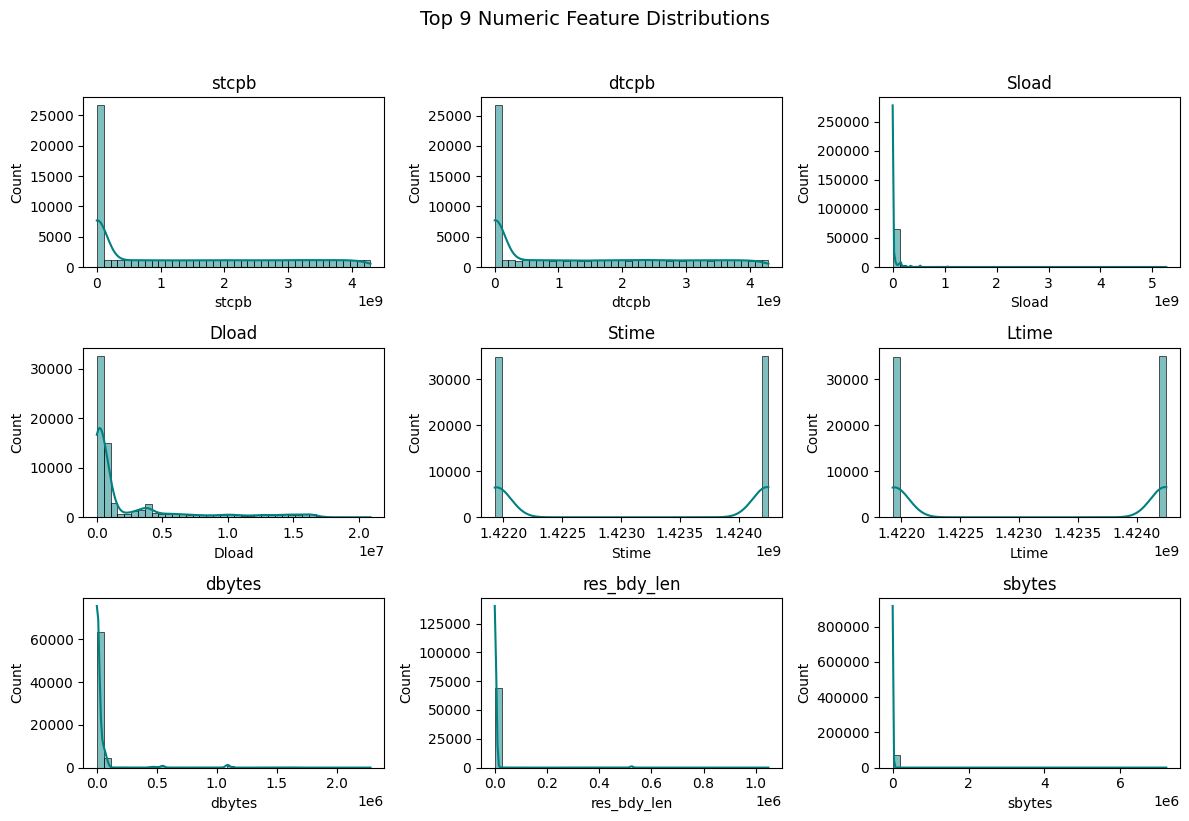

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns.tolist()
top_num = df[num_cols].var().sort_values(ascending=False).head(9).index.tolist()

plt.figure(figsize=(12,8))
for i, col in enumerate(top_num, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=40, color='teal', kde=True)
    plt.title(col)
plt.suptitle("Top 9 Numeric Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

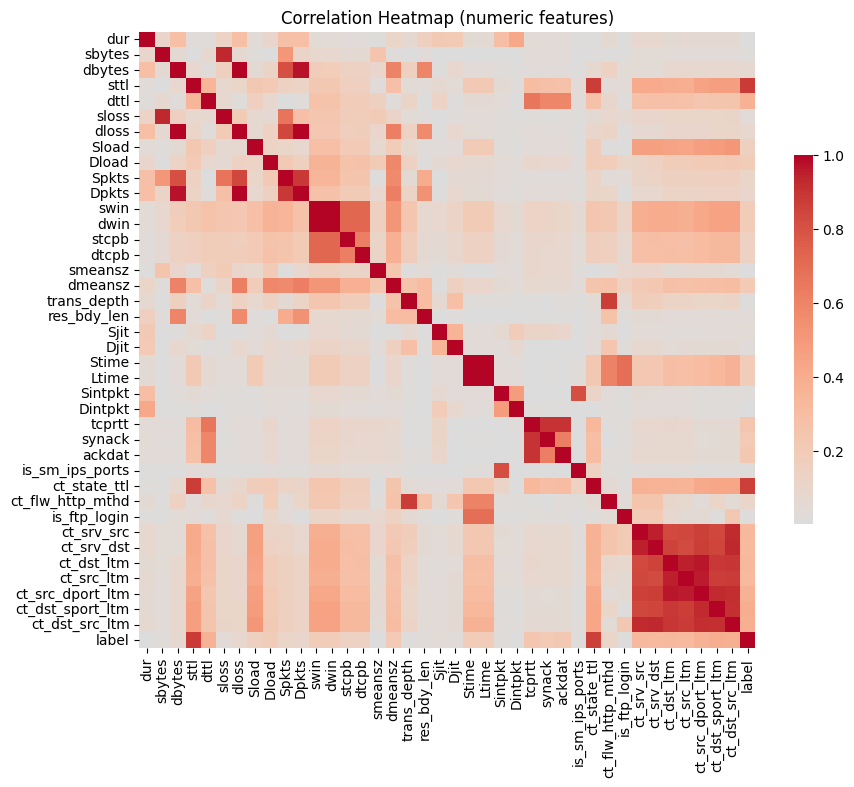

In [18]:
corr = df[num_cols].corr().abs()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.6})
plt.title("Correlation Heatmap (numeric features)")
plt.show()

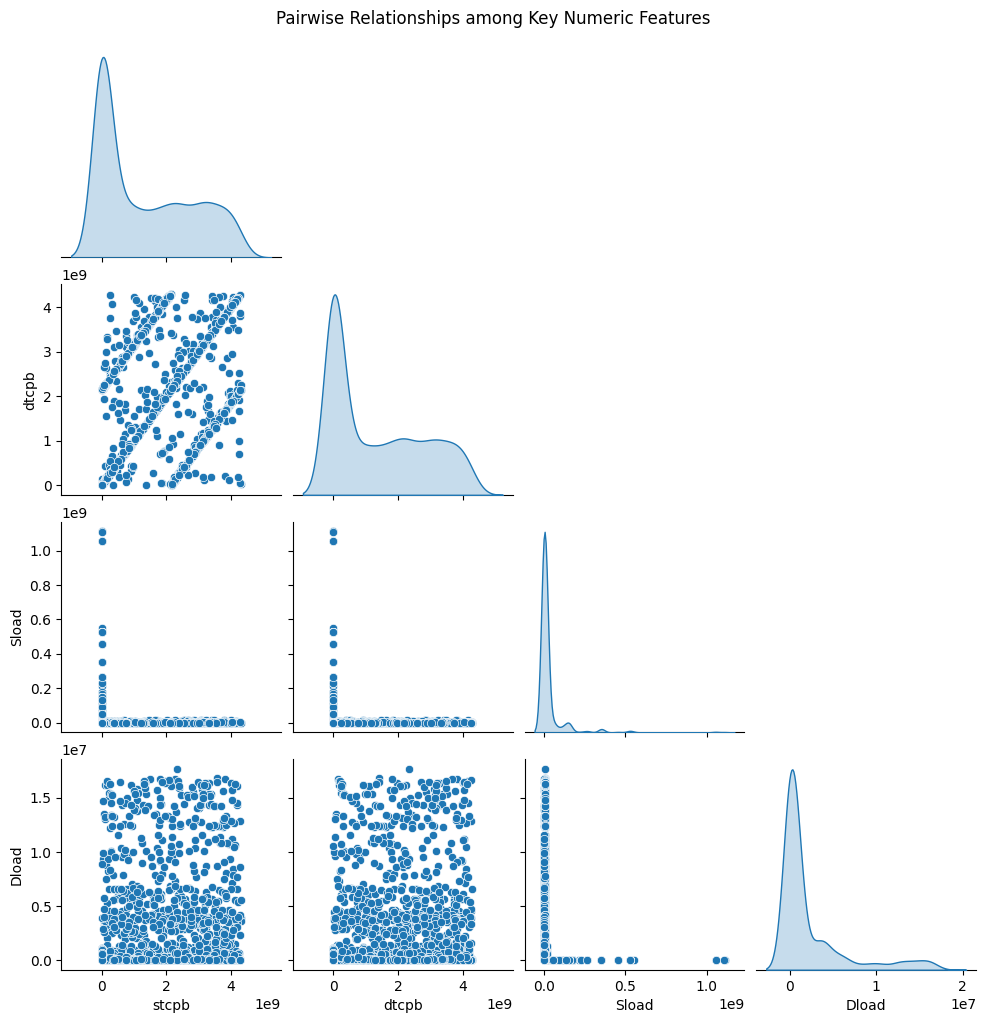

In [19]:
sample = df.sample(min(len(df), 2000), random_state=42)
sns.pairplot(sample[top_num[:4]], diag_kind='kde', corner=True)
plt.suptitle("Pairwise Relationships among Key Numeric Features", y=1.02)
plt.show()

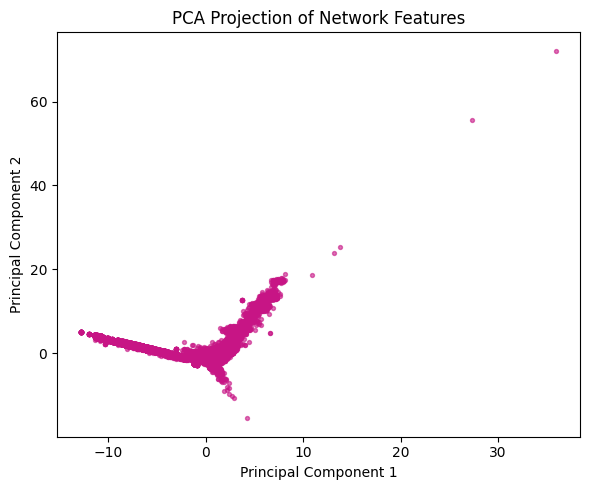

Explained variance ratio: [0.22607772 0.11716359]


In [20]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaled = StandardScaler().fit_transform(df[num_cols].fillna(0))
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, alpha=0.6, color='mediumvioletred')
plt.title("PCA Projection of Network Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

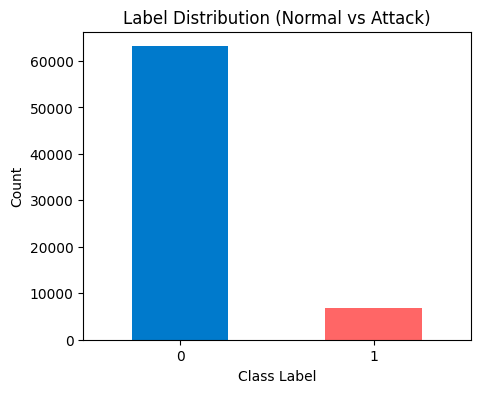

Class balance:
 label
0    0.901914
1    0.098086
Name: proportion, dtype: float64


In [21]:
plt.figure(figsize=(5,4))
df['label'].value_counts().plot(kind='bar', color=['#007acc', '#ff6666'])
plt.title("Label Distribution (Normal vs Attack)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Class balance:\n", df['label'].value_counts(normalize=True))

## Step 2 – Data Preprocessing and Train/Test Split

In [22]:
# === Step 2: Preprocessing & Train/Test Split ===
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Split BEFORE any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Fit preprocess ONLY on training
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc = preprocess.transform(X_test)

# Then apply SMOTE ONLY on X_train_proc, y_train
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_proc, y_train)

print(f"Split complete: Train={X_train.shape}, Test={X_test.shape}")

# --- Define numeric & categorical preprocessors ---
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# --- Combine in a ColumnTransformer ---
preprocess = ColumnTransformer([
    ("num", numeric_tf, selected_numeric),
    ("cat", categorical_tf, cat_cols)
])

print("Preprocessing pipeline is ready.")

# --- Optional: Fit-transform a small subset to verify ---
_ = preprocess.fit_transform(X_train.head(200))
print("Pipeline test passed on sample batch.")

Split complete: Train=(52500, 48), Test=(17500, 48)
Preprocessing pipeline is ready.
Pipeline test passed on sample batch.


## Step 3 – Feature Selection (Mutual Information + EFS)

In [ ]:
## Step 3: Feature Selection (Mutual Information + EFS)

from sklearn.feature_selection import mutual_info_classif
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.linear_model import LogisticRegression
import pandas as pd, numpy as np, json, time

# Use numeric columns only
numeric_mask = X_train.apply(lambda s: np.issubdtype(s.dtype, np.number))
num_cols_valid = X_train.columns[numeric_mask].tolist()

# --- Mutual Information Ranking ---
mi = mutual_info_classif(X_train[num_cols_valid].fillna(0), y_train, random_state=42)
mi_series = pd.Series(mi, index=num_cols_valid).sort_values(ascending=False)

print("Top 10 Features by Mutual Information:")
display(mi_series.head(10))

# --- Exhaustive Feature Selector (EFS) on subset ---
efs_model = LogisticRegression(max_iter=2000, solver='liblinear')
efs = EFS(
    efs_model,
    min_features=5,
    max_features=10,
    scoring='accuracy',
    print_progress=True,
    cv=3,
    n_jobs=-1
)

# Run EFS on top 20 MI features (to reduce runtime)
top_mi_features = mi_series.head(20).index.tolist()
efs.fit(X_train[top_mi_features].fillna(0), y_train)

best_features = list(efs.best_feature_names_)
print("\n Best features selected by EFS:\n", best_features)

# Save selected features for future runs
os.makedirs("outputs", exist_ok=True)
json.dump(best_features, open("outputs/selected_numeric.json", "w"))


Top 10 Features by Mutual Information:


sttl            0.280424
ct_state_ttl    0.280278
sbytes          0.277208
Sload           0.214768
smeansz         0.214541
dttl            0.205164
dbytes          0.189738
dmeansz         0.171557
dur             0.151210
Dload           0.150220
dtype: float64

In [11]:
!pip install imblearn

## Step 4 – Supervised Models (RandomForest + XGBoost)

In [14]:
# === Step 3: Feature Balancing + Model Training ===
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

# --- Fit preprocessing pipeline on training data ---
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc = preprocess.transform(X_test)

print(" Data preprocessing done for model training.")
print(f"Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")

# --- Balance using SMOTE ---
sm = SMOTE(random_state=42, sampling_strategy='auto')
X_train_bal, y_train_bal = sm.fit_resample(X_train_proc, y_train)

print("  After SMOTE balancing:")
print(f"Training samples before: {len(y_train)}, after: {len(y_train_bal)}")

# --- Train RandomForest ---
rf = RandomForestClassifier(
    n_estimators=150, max_depth=12, random_state=42, n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)

rf_pred = rf.predict(X_test_proc)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_proc)[:,1])

print("\n RandomForest Results")
print(classification_report(y_test, rf_pred, digits=3))
print(f"ROC-AUC: {rf_auc:.3f}")

# --- Train XGBoost ---
xgb = XGBClassifier(
    n_estimators=150, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric="logloss", n_jobs=-1
)
xgb.fit(X_train_bal, y_train_bal)

xgb_pred = xgb.predict(X_test_proc)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test_proc)[:,1])

print("\n XGBoost Results")
print(classification_report(y_test, xgb_pred, digits=3))
print(f"ROC-AUC: {xgb_auc:.3f}")


 Data preprocessing done for model training.
Train: (52500, 55), Test: (17500, 55)
  After SMOTE balancing:
Training samples before: 52500, after: 94700

 RandomForest Results
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     15784
           1      0.997     0.998     0.997      1716

    accuracy                          0.999     17500
   macro avg      0.998     0.999     0.998     17500
weighted avg      0.999     0.999     0.999     17500

ROC-AUC: 1.000

 XGBoost Results
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     15784
           1      0.999     0.997     0.998      1716

    accuracy                          1.000     17500
   macro avg      0.999     0.998     0.999     17500
weighted avg      1.000     1.000     1.000     17500

ROC-AUC: 1.000


In [15]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([47350,  5150]))
(array([0, 1]), array([15784,  1716]))


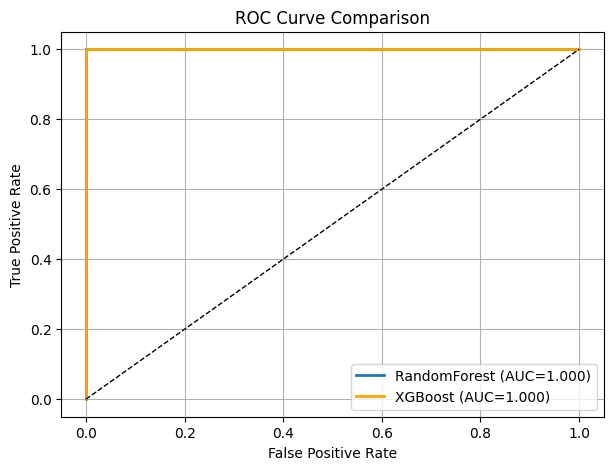

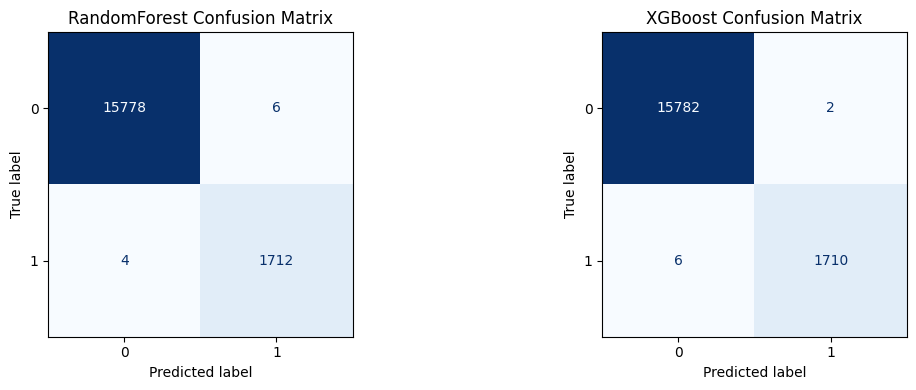

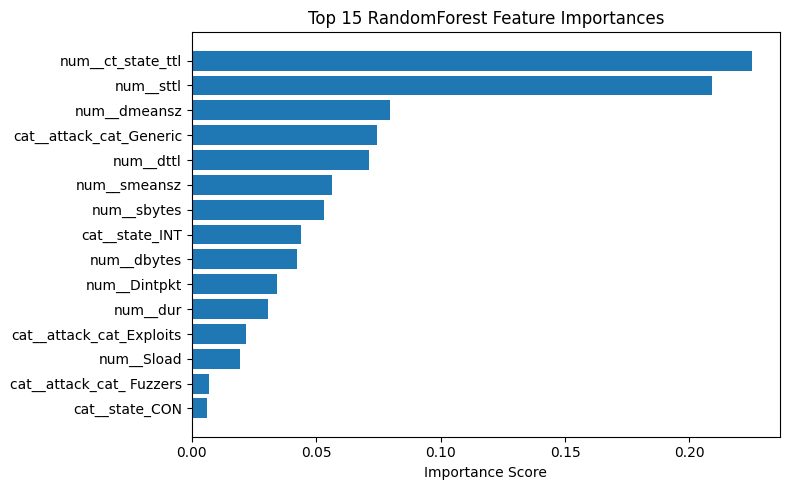

In [16]:
# === Step 4: Evaluation & Visualization ===
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# --- ROC curves ---
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test_proc)[:,1])
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb.predict_proba(X_test_proc)[:,1])

rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7,5))
plt.plot(rf_fpr, rf_tpr, label=f"RandomForest (AUC={rf_auc:.3f})", lw=2)
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC={xgb_auc:.3f})", lw=2, color='orange')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, model, name in zip(
    axes, [rf, xgb], ["RandomForest", "XGBoost"]
):
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test_proc, y_test, cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

# --- Feature Importances ---
importances = rf.feature_importances_
feat_names = preprocess.get_feature_names_out()

indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(8,5))
plt.barh(np.array(feat_names)[indices][::-1], importances[indices][::-1])
plt.title("Top 15 RandomForest Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
